In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from LSSVMClassification import LSSVMClassification

In [12]:
# Read dataset 
df = pd.read_excel("Chemical_Fingerprint_Singles_Normalized_Classes.xlsx")

X = df.drop(columns=["BandGap", "Class"])
y = df["Class"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize 
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Take a stratified subset for hyperparameter tuning 
subset_size = 100       # change to 200 to compare

sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=subset_size,
    random_state=42
)

subset_idx, _ = next(sss.split(X_train, y_train))

X_subset = X_train[subset_idx]
y_subset = y_train.iloc[subset_idx]

print(f"Subset size: {len(y_subset)}")


Subset size: 100


### Define LS-SVM model

In [ ]:
# LS-SVM model 
model = LSSVMClassification(kernel="rbf")

### Define the hyperparameter space 

In [ ]:
# Parameter distribution
param_dist = {
    "gamma": [0.01, 0.1, 1, 10, 100],
    "sigma": [0.01, 0.1, 0.5, 1, 2, 5, 10]
}

### Hyperparameter search methods 

In [42]:
def evaluate_search(search, name):

    start = time.time()

    search.fit(X_subset, y_subset)

    runtime = time.time() - start

    best_model = LSSVMClassification(
        kernel="rbf",
        gamma=search.best_params_["gamma"],
        sigma=search.best_params_["sigma"]
    )

    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)

    return {
        "Method": name,
        "Gamma": search.best_params_["gamma"],
        "Sigma": search.best_params_["sigma"],
        "CV Accuracy": search.best_score_,
        "Test Accuracy": accuracy_score(y_test,y_pred),
        "Runtime (s)": runtime
    }



In [43]:
# grid search 
grid = GridSearchCV(
    model,
    param_grid=param_dist,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_results = evaluate_search(grid,"GridSearchCV")

# random search 
random = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_results = evaluate_search(random,"RandomizedSearchCV")

# Halving grid search 
halving_grid = HalvingGridSearchCV(
    model,
    param_grid=param_dist,
    factor=2,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

halving_grid_results = evaluate_search(
    halving_grid,
    "HalvingGridSearchCV"
)

# halving random search 
halving_random = HalvingRandomSearchCV(
    model,
    param_distributions=param_dist,
    factor=2,
    cv=5,
    random_state=42,
    n_jobs=-1
)

halving_random_results = evaluate_search(
    halving_random,
    "HalvingRandomSearchCV"
)



In [44]:
# comparison table 
comparison = pd.DataFrame([
    grid_results,
    random_results,
    halving_grid_results,
    halving_random_results
])

comparison

,Method,Gamma,Sigma,CV Accuracy,Test Accuracy,Runtime (s)
0,GridSearchCV,1.0,5.0,0.630,0.618040,4.849420
1,RandomizedSearchCV,1.0,5.0,0.630,0.618040,0.300974
2,HalvingGridSearchCV,10.0,1.0,0.625,0.565702,1.143877
3,HalvingRandomSearchCV,0.1,0.1,0.575,0.596882,0.397628


### Train the final model 

In [45]:
best_model = LSSVMClassification(
    kernel="rbf",
    gamma=random.best_params_["gamma"],
    sigma=random.best_params_["sigma"]
)

best_model.fit(X_train, y_train)

### Evaluate the final model

In [46]:
# predictions 
y_pred = best_model.predict(X_test)

# evaluation 
test_accuracy = accuracy_score(y_test,y_pred)

print(f"Test Accuracy: {test_accuracy:.3f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.618

Classification Report
              precision    recall  f1-score   support

          -1       0.53      0.49      0.51       360
           1       0.67      0.70      0.69       538

    accuracy                           0.62       898
   macro avg       0.60      0.60      0.60       898
weighted avg       0.61      0.62      0.62       898



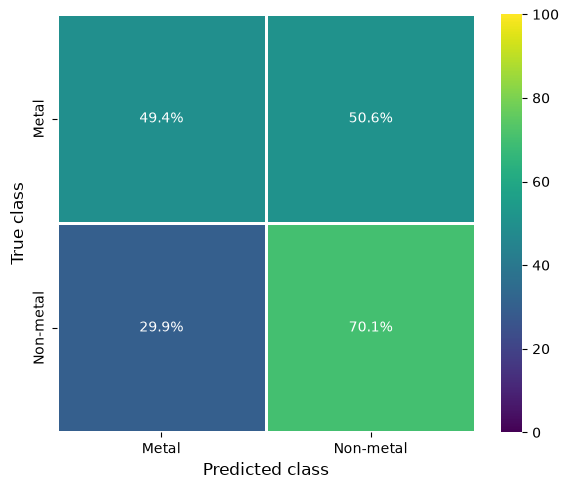

In [47]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    vmin=0,
    vmax=100,
    linewidths=1,
    linecolor="white",
    cbar=True,
    xticklabels=["Metal","Non-metal"],
    yticklabels=["Metal","Non-metal"]
)

plt.xlabel("Predicted class", fontsize=12)
plt.ylabel("True class", fontsize=12)

for text in plt.gca().texts:
    text.set_text(text.get_text() + "%")

plt.tight_layout()
plt.show()

### Hyperparameter visualization 

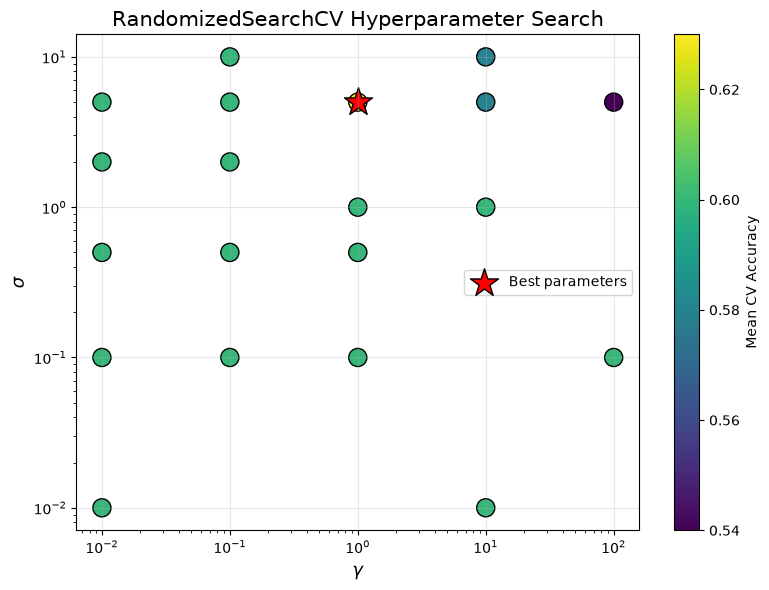

In [51]:
results = pd.DataFrame(random.cv_results_)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    results["param_gamma"].astype(float),
    results["param_sigma"].astype(float),
    c=results["mean_test_score"],
    cmap="viridis",
    s=170,
    edgecolor="black"
)

plt.scatter(
    random.best_params_["gamma"],
    random.best_params_["sigma"],
    marker="*",
    s=450,
    color="red",
    edgecolor="black",
    label="Best parameters"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$\gamma$", fontsize=13)
plt.ylabel(r"$\sigma$", fontsize=13)

plt.title("RandomizedSearchCV Hyperparameter Search", fontsize=15)

cbar = plt.colorbar(scatter)
cbar.set_label("Mean CV Accuracy")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
halving = HalvingGridSearchCV(
    estimator=model,
    param_grid=param_dist,
    factor=2,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

halving.fit(X_subset, y_subset)

print(halving.best_params_)
print(halving.best_score_)

n_iterations: 4
n_required_iterations: 6
n_possible_iterations: 4
min_resources_: 10
max_resources_: 100
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 35
n_resources: 10
Fitting 5 folds for each of 35 candidates, totalling 175 fits
----------
iter: 1
n_candidates: 18
n_resources: 20
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 2
n_candidates: 9
n_resources: 40
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 3
n_candidates: 5
n_resources: 80
Fitting 5 folds for each of 5 candidates, totalling 25 fits
{'gamma': 10, 'sigma': 2}
0.6125


In [35]:
halving_random = HalvingRandomSearchCV(
    estimator=model,
    param_distributions=param_dist,
    factor=2,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

halving_random.fit(X_subset, y_subset)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 10
max_resources_: 100
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 10
n_resources: 10
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------
iter: 1
n_candidates: 5
n_resources: 20
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 2
n_candidates: 3
n_resources: 40
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 3
n_candidates: 2
n_resources: 80
Fitting 5 folds for each of 2 candidates, totalling 10 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LSSVMClassifi...(kernel='rbf')
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'gamma': [0.01, 0.1, ...], 'sigma': [0.01, 0.1, ...]}"
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for subsampling the datasetwhen `resources != 'n_samples'`. Also used for random uniformsampling from lists of possible values instead of scipy.statsdistributions.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int or None, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"verbose verbose: intControls the verbosity: the higher, the more messages.",2
,"n_candidates n_candidates: ""exhaust"" or int, default=""exhaust""The number of candidate parameters to sample, at the firstiteration. Using 'exhaust' will sample enough candidates so that thelast iteration uses as many resources as possible, based on`min_resources`, `max_resources` and `factor`. In this case,`min_resources` cannot be 'exhaust'.",'exhaust'
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'n_samples'
,"max_resources max_resources: int, default='auto'The maximum number of resources that any candidate is allowed to usefor a given iteration. By default, this is set ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",'auto'
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='smallest'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming. 'exhaust' isn't available when `n_candidates='exhaust'`.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",'smallest'
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search proces

In [36]:
print("Best parameters:", halving_random.best_params_)
print("Best CV accuracy:", halving_random.best_score_)

Best parameters: {'sigma': 0.1, 'gamma': 0.1}
Best CV accuracy: 0.575


In [37]:
best_model = LSSVMClassification(
    kernel="rbf",
    gamma=halving_random.best_params_["gamma"],
    sigma=halving_random.best_params_["sigma"]
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.5968819599109132
